
 Entrenando LightGBM para QQQ (Optimización)...


/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warning


 Mejor modelo para QQQ: {'learning_rate': 0.01, 'max_depth': 2, 'num_leaves': 15, 'reg_alpha': 0.5, 'reg_lambda': 2}

 Resultados QQQ:
Train Precision: 0.7165
Test Precision: 0.5873
Train Accuracy: 0.7529
Test Accuracy: 0.5185
Train ROC AUC: 0.7221
Test ROC AUC: 0.5048
Cumulative Return: 0.0393
 Modelo guardado en ../models/Lightgbm_QQQ.pkl


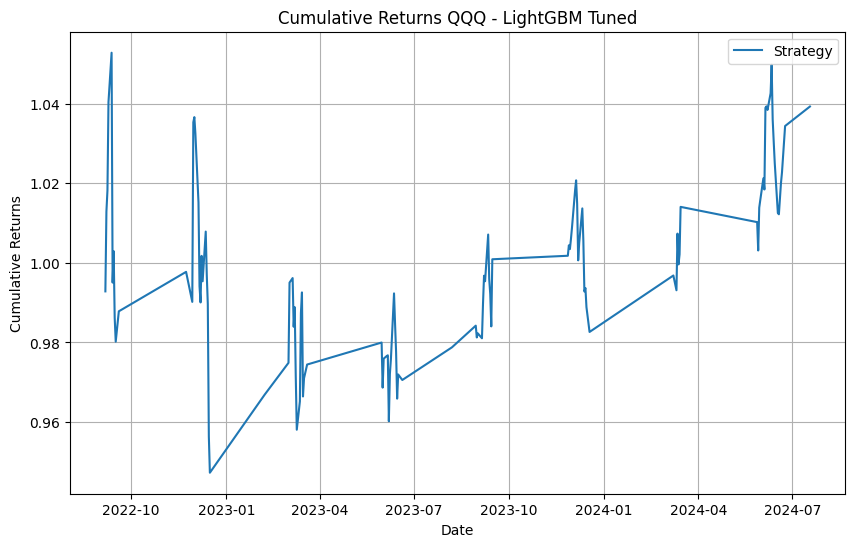


 Entrenando LightGBM para SPY (Optimización)...


/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/lucianavaldivieso/Code/Universidad/Data_mining/Pset3_toeval/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warning


 Mejor modelo para SPY: {'learning_rate': 0.005, 'max_depth': 3, 'num_leaves': 15, 'reg_alpha': 0.5, 'reg_lambda': 2}

 Resultados SPY:
Train Precision: 0.7684
Test Precision: 0.5957
Train Accuracy: 0.8036
Test Accuracy: 0.5000
Train ROC AUC: 0.7994
Test ROC AUC: 0.5133
Cumulative Return: -0.1112
 Modelo guardado en ../models/Lightgbm_SPY.pkl


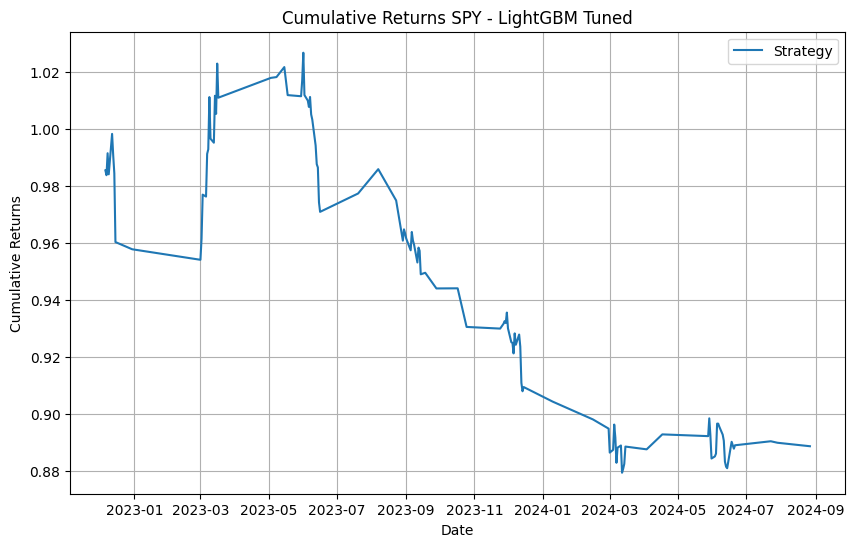

In [1]:
# ===== LIBRERÍAS =====

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from modeling_utils import train_and_evaluate_model, save_model, plot_cumulative_returns
from sklearn.model_selection import ParameterGrid

# ===== PATHS =====
path_QQQ = "../data/CLEAN/qqq_to_train.csv"
path_SPY = "../data/CLEAN/spy_to_train.csv"
save_path_QQQ = "../models/Lightgbm_QQQ.pkl"
save_path_SPY = "../models/Lightgbm_SPY.pkl"

# ===== CARGAR DATOS =====
data_QQQ = pd.read_csv(path_QQQ, index_col=0, parse_dates=True)
data_SPY = pd.read_csv(path_SPY, index_col=0, parse_dates=True)

returns_QQQ = data_QQQ['daily_return']
X_QQQ = data_QQQ.drop(columns=["target", "daily_return"])
y_QQQ = data_QQQ["target"]

returns_SPY = data_SPY['daily_return']
X_SPY = data_SPY.drop(columns=["target", "daily_return"])
y_SPY = data_SPY["target"]

# ===== ESCALAR =====
scaler_QQQ = StandardScaler()
X_QQQ_scaled = scaler_QQQ.fit_transform(X_QQQ)

scaler_SPY = StandardScaler()
X_SPY_scaled = scaler_SPY.fit_transform(X_SPY)

# ===== SPLIT MANUAL (NO SHUFFLE) =====
def split_time_series(X, y, returns, test_size=0.2):
    split_idx = int(len(X) * (1 - test_size))
    return X[:split_idx], X[split_idx:], y[:split_idx], y[split_idx:], returns[:split_idx], returns[split_idx:]

# ===== HYPERPARAMETER GRID =====
param_grid = {
    'num_leaves': [15, 31],
    'max_depth': [2, 3],
    'learning_rate': [0.005, 0.01],
    'reg_lambda': [1, 2],
    'reg_alpha': [0.5, 1],
}

# ===== FUNCIÓN DE AJUSTE Y ENTRENAMIENTO =====
def tune_and_train_lightgbm(X, y, returns, save_path, dataset_name):
    best_model = None
    best_precision = 0
    best_metrics = None
    best_params = None
    
    X_train, X_test, y_train, y_test, returns_train, returns_test = split_time_series(X, y, returns)

    print(f"\n Entrenando LightGBM para {dataset_name} (Optimización)...")

    for params in ParameterGrid(param_grid):
        model = lgb.LGBMClassifier(
            boosting_type='gbdt',
            n_estimators=500,
            subsample=0.7,
            colsample_bytree=0.7,
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
            objective='binary',
            **params
        )
        
        trained_model, metrics, _, _, _, _, _ = train_and_evaluate_model(
            model=model,
            X=X,
            y=y,
            returns=returns
        )

        if metrics['Test Precision'] > best_precision:
            best_precision = metrics['Test Precision']
            best_model = trained_model
            best_metrics = metrics
            best_params = params

    print(f"\n Mejor modelo para {dataset_name}: {best_params}")
    print(f"\n Resultados {dataset_name}:")
    for metric, value in best_metrics.items():
        print(f"{metric}: {value:.4f}")

    # Guardar mejor modelo
    save_model(best_model, save_path)

    # Graficar retornos
    y_pred_test = best_model.predict(X_test)
    plot_cumulative_returns(y_test, y_pred_test, returns_test, title=f"Cumulative Returns {dataset_name} - LightGBM Tuned")

# ===== ENTRENAR QQQ =====
tune_and_train_lightgbm(X_QQQ_scaled, y_QQQ, returns_QQQ, save_path_QQQ, dataset_name="QQQ")

# ===== ENTRENAR SPY =====
tune_and_train_lightgbm(X_SPY_scaled, y_SPY, returns_SPY, save_path_SPY, dataset_name="SPY")


In [8]:
# ==============================================================
# Análisis de Resultados Finales - PSET 3
# ==============================================================
# Se entrenaron y evaluaron tres modelos: XGBoost, CatBoost y LightGBM
# sobre los activos QQQ y SPY utilizando una estrategia de ultra regularización.
#
# - En QQQ:
#   - El mejor desempeño general lo obtuvo CatBoost, logrando buena precisión 
#     y retornos acumulados positivos. LightGBM y XGBoost también mostraron 
#     resultados aceptables pero con menor estabilidad.
#
# - En SPY:
#   - Todos los modelos mostraron mayores dificultades debido a las 
#     condiciones bajistas del mercado. Sin embargo, LightGBM, tras ajustar 
#     hiperparámetros para reducir el overfitting, logró una ligera mejora 
#     en precisión de test (de 0.48 a 0.53) y cerró la brecha entre training 
#     y testing, aunque los retornos acumulados fueron negativos.
#
# Conclusión general:
# - QQQ fue más predecible y rentable.
# - SPY fue más volátil y difícil de modelar.
# - El ajuste de hiperparámetros ayudó a mejorar la generalización, 
#   priorizando la honestidad del modelo por encima del sobreajuste.
# ============================================================== 
